In [20]:
import xarray as xr
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os
import pandas as pd

In [ ]:
ds = xr.open_dataset("/scratch/leko/ccic_record/data/processed/cloudsat_time_series.nc")
ccic = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018_2019_utc.nc')
era5 = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ERA5/ERA5_diurnal_climatology_2018_2019_utc.nc')
ccic = ccic.tiwp.mean(dim = 'hour_of_day').mean(dim= 'lon')
ccic_seasons = []
for months in seasons.values():
    ccic_season = ccic.sel(month = months).mean('month')
    ccic_seasons.append(ccic_season)
ccic_seasons = xr.concat(ccic_seasons, dim = 'season')
ccic_seasons['season'] = list(seasons.keys())
era5 = era5.tiwp.mean(dim = 'hour_of_day').mean(dim= 'lon')
era5_seasons = []
for months in seasons.values():
    era5_season = era5.sel(month = months).mean('month')
    era5_seasons.append(era5_season)
era5_seasons = xr.concat(era5_seasons, dim = 'season')
era5_seasons['season'] = list(seasons.keys())
ds_sel = ds.sel(year = slice('2018-12-31T00:00:00.000000000', '2019-12-31T00:00:00.000000000'))
ds_mean = ds_sel.groupby('month').mean('time').mean('year')

In [41]:
seasons = {
        "DJF": [12, 1, 2],
        "MAM": [3, 4, 5],
        "JJA": [6, 7, 8],
        "SON": [9, 10, 11]
    }

In [ ]:
ds_seasons = []
for months in seasons.values():
    ds_season = ds_mean.sel(month = months).mean('month')
    ds_seasons.append(ds_season)
ds_seasons = xr.concat(ds_seasons, dim = 'season')
ds_seasons['season'] = list(seasons.keys())
ds_seasons_zonal = ds_seasons.mean('longitude')

In [ ]:
vars = ['tiwp_monthly_2cice', 'tiwp_monthly_dardar']
season_linestyles = ['-', '--', '-.', ':']
season_names = ['DJF', 'JJA',]
ccic_color = 'blue'
era5_color = 'red'
ice_color = 'black'
dardar_color = 'grey'
colors = [ice_color, dardar_color]
plt.figure(figsize=(10, 6))
for i,var in enumerate(vars):
    data = ds_seasons_zonal[var]
    if var == 'tiwp_monthly_dardar':
        data = data.where(data < 1e3)
    for j, season in enumerate(['DJF', 'JJA']):
        plt.plot(ds_seasons_zonal['latitude'], data.sel(season=season), label=f'{var} - {season}', linestyle=season_linestyles[j], color=colors[i])
        plt.plot(ccic_seasons['lat'], ccic_seasons.sel(season=season), label=f'CCIC - {season}', linestyle=season_linestyles[j], color=ccic_color)
        plt.plot(era5_seasons['lat'], era5_seasons.sel(season=season), label=f'ERA5 - {season}', linestyle=season_linestyles[j], color=era5_color)

plt.xlabel('Latitude')
plt.ylabel('Mean TIWP')
plt.title('Zonal Mean TIWP by Season')
plt.legend()
plt.grid()
plt.show()
    

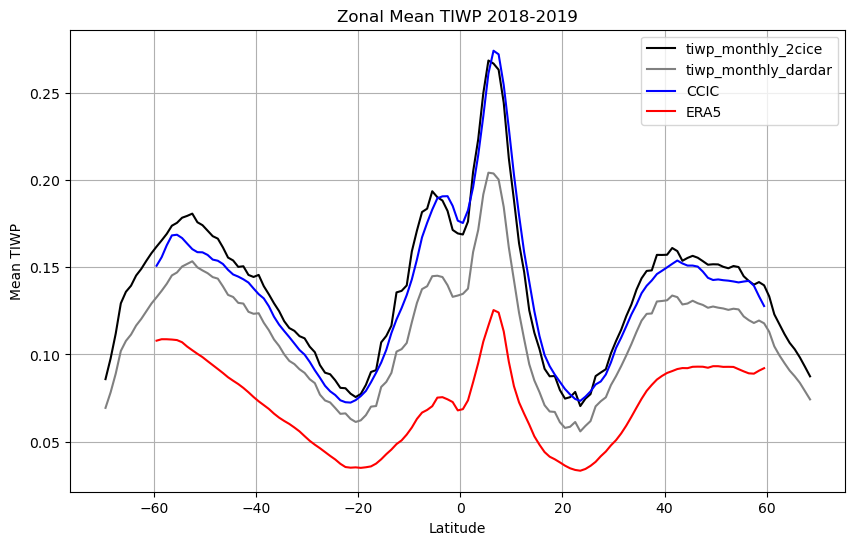

In [52]:
ccic_color = 'blue'
era5_color = 'red'
ice_color = 'black'
dardar_color = 'grey'
colors = [ice_color, dardar_color]
plt.figure(figsize=(10, 6))
for i,var in enumerate(vars):
    data = ds_seasons_zonal[var]
    if var == 'tiwp_monthly_dardar':
        data = data.where(data < 1e3)
    plt.plot(ds_seasons_zonal['latitude'], data.mean('season'), label=f'{var}', color=colors[i])
plt.plot(ccic_seasons['lat'], ccic_seasons.mean('season'), label=f'CCIC', color=ccic_color)
plt.plot(era5_seasons['lat'], era5_seasons.mean('season'), label=f'ERA5', color=era5_color)

plt.xlabel('Latitude')
plt.ylabel('Mean TIWP')
plt.title('Zonal Mean TIWP 2018-2019')
plt.legend()
plt.grid()
plt.show()

In [32]:
imerg = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/30min/2018/2018_01_IMERG_diurnal_mean.nc')

In [30]:
ccic = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/2018/ccic_cpcir_2018_01_monthlymean_1deg_tiwp.nc')

/tmp/ipykernel_2265983/3841825480.py:1: FutureWarning: In a future version, xarray will not decode the variable 'hour_of_day' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ccic = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/2018/ccic_cpcir_2018_01_monthlymean_1deg_tiwp.nc')


In [31]:
ccic.tiwp_stratified

<xarray.DataArray 'tiwp_stratified' (hour_of_day: 48, latitude: 120,
                                     longitude: 360)> Size: 8MB
[2073600 values with dtype=float32]
Coordinates:
  * hour_of_day  (hour_of_day) timedelta64[ns] 384B 00:00:00 ... 23:30:00
  * latitude     (latitude) float64 960B -59.5 -58.5 -57.5 ... 57.5 58.5 59.5
  * longitude    (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Attributes:
    ancillary_variables:  tiwp_ci p_tiwp
    long_name:            Vertically-integrated concentration of frozen hydro...
    standard_name:        atmosphere_mass_content_of_cloud_ice
    units:                kg m-2

In [34]:
# conver to hour_of_day timedelta64[ns] to match ccic
imerg['hour_of_day'] = pd.to_timedelta(imerg['time'].dt.hour, unit='h')

In [36]:
imerg.precipitation

<xarray.DataArray 'precipitation' (time: 48, lon: 360, lat: 180)> Size: 12MB
[3110400 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 384B 2018-01-31 ... 2018-01-31T23:30:00
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes:
    units:             mm/hr
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    CodeMissingValue:  -9999.9
    LongName:          \nComplete merged microwave-infrared (gauge-adjusted)\...

In [25]:
imerg['hour_of_day'] 

<xarray.DataArray 'hour_of_day' (hour_of_day: 48)> Size: 384B
array([             0,              0,  3600000000000,  3600000000000,
        7200000000000,  7200000000000, 10800000000000, 10800000000000,
       14400000000000, 14400000000000, 18000000000000, 18000000000000,
       21600000000000, 21600000000000, 25200000000000, 25200000000000,
       28800000000000, 28800000000000, 32400000000000, 32400000000000,
       36000000000000, 36000000000000, 39600000000000, 39600000000000,
       43200000000000, 43200000000000, 46800000000000, 46800000000000,
       50400000000000, 50400000000000, 54000000000000, 54000000000000,
       57600000000000, 57600000000000, 61200000000000, 61200000000000,
       64800000000000, 64800000000000, 68400000000000, 68400000000000,
       72000000000000, 72000000000000, 75600000000000, 75600000000000,
       79200000000000, 79200000000000, 82800000000000, 82800000000000],
      dtype='timedelta64[ns]')
Coordinates:
  * hour_of_day  (hour_of_day) timedelta64[ns] 384B 00:00:00 ... 23:00:00

In [28]:
imerg.sortby('hour_of_day').mean('time')

<xarray.Dataset> Size: 264kB
Dimensions:        (bnds: 2, lon: 360, lat: 180, hour_of_day: 48)
Coordinates:
  * lon            (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat            (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * hour_of_day    (hour_of_day) timedelta64[ns] 384B 00:00:00 ... 23:00:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds      (bnds) datetime64[ns] 16B 2018-01-01T11:45:00 2018-01-31T1...
    precipitation  (lon, lat) float32 259kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    CDI:                                    Climate Data Interface version 2....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH/07;\n...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR.MS.MRG.3IMERG.20180101-S00...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    history:                                Sun Jan 25 18:35:22 2026: cdo -O ...
    CDO:                                    Climate Data Operators version 2....